In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno

sys.path.insert(0, str(Path.cwd().parent))

from utils.geo import (
    CUNDINAMARCA_BBOX,
    count_outside_bogota,
    outside_bbox_mask,
)

from utils.plotting import EDAPlotter
from utils.triple_plot import normality_report

In [2]:
df = pd.read_csv("../data/fincaraiz_venta_bogota_20260803.csv")

## Variable dictionary

| Variable | Unit | Description |
|---|---|---|
| `listing_id` | id | Unique identifier of the listing on FincaRaíz. |
| `operation` | category | Transaction advertised: `venta` (sale) or `arriendo` (rent). |
| `property_type` | category | Class of property: `apartamento`, `casa`, `oficina`, `bodega`, `local`, `lote`, and similar. |
| `price_amount` | COP | Asking price published in the listing. |
| `price_currency` | category | Currency the asking price is quoted in. |
| `admin_fee` | COP / month | Monthly building administration fee (*administración*). |
| `total_monthly_cost` | COP / month | Rent plus administration fee; defined for rental listings. |
| `price_per_m2` | COP / m² | Asking price divided by built area. |
| `area_built_m2` | m² | Constructed area of the property. |
| `area_private_m2` | m² | Private interior area of the unit. |
| `bedrooms` | count | Number of bedrooms. |
| `bathrooms` | count | Number of bathrooms. |
| `parking_spaces` | count | Number of parking spaces included with the property. |
| `stratum` | ordinal 1–6 | Colombian socio-economic stratum assigned to the address. |
| `floor` | floor number | Floor of the building on which the unit sits. |
| `floors_total` | count | Number of floors in the building. |
| `age_bracket_code` | ordinal 0–5 | Age of the property as a bracket: 0 brand new, 1 under 1 year, 2 = 1–8, 3 = 9–15, 4 = 16–30, 5 over 30 years. |
| `age_bracket_label` | category | Spanish text label of the age bracket. |
| `construction_state` | category | Condition declared in the listing: `Usado`, `Excelente estado`, `En construcción`, and similar. |
| `city` | name | Municipality where the property is located. |
| `locality` | category | Bogotá *localidad* containing the property. |
| `neighborhood` | name | Neighbourhood (*barrio*) of the property. |
| `address_text` | text | Street address as published in the listing. |
| `latitude` | degrees (WGS84) | Latitude of the property's map location. |
| `longitude` | degrees (WGS84) | Longitude of the property's map location. |
| `amenities` | list (`\|`-separated) | Amenities and features attributed to the property or its building. |
| `agency_name` | name | Real-estate agency publishing the listing. |
| `publisher_type` | category | Kind of publisher: `inmobiliaria` (agency) or `desarrollador` (developer). |
| `published_at` | date (YYYY-MM-DD) | Date the listing was first published. |
| `updated_at` | date (YYYY-MM-DD) | Date the listing was last updated. |
| `source_url` | URL | Web address of the listing. |


# Basic descriptive statistics

In [3]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# Run describe again
df.describe()

,listing_id,price_amount,admin_fee,total_monthly_cost,price_per_m2,area_built_m2,area_private_m2,bedrooms,bathrooms,parking_spaces,stratum,floor,floors_total,age_bracket_code,latitude,longitude
count,31252.00,31252.00,17641.00,0.00,25206.00,25206.00,23129.00,31252.00,31252.00,20470.00,30658.00,15469.00,31252.00,30490.00,31252.00,31252.00
mean,180871972.11,3644250869.26,4528528.89,NaN,17804385.75,3125.00,1311.98,2.71,2.72,2.61,5.87,5.13,1.00,3.46,4.69,-74.06
std,46119900.68,96776331244.01,71313162.52,NaN,288143681.95,428453.68,104232.03,2.73,2.21,4.04,13.27,19.12,4.69,1.42,0.20,1.07
min,1277484.00,0.00,1.00,NaN,0.00,0.10,0.00,-1.00,0.00,-2.00,1.00,1.00,0.00,0.00,-0.04,-105.35
25%,192663856.50,440000000.00,300000.00,NaN,4470827.36,62.00,60.00,1.00,1.00,1.00,3.00,2.00,0.00,2.00,4.65,-74.09
50%,193513452.00,860000000.00,649000.00,NaN,6045240.00,134.00,130.00,3.00,2.00,2.00,4.00,3.00,0.00,4.00,4.69,-74.07
75%,193808646.25,1790000000.00,1200000.00,NaN,8199852.41,300.00,270.00,4.00,4.00,3.00,5.00,5.00,1.00,5.00,4.72,-74.05
max,194064832.00,13789000000000.00,2147483647.00,NaN,15151515151.52,68000000.00,14390000.00,68.00,80.00,127.00,110.00,902.00,403.00,5.00,22.73,0.00


In [4]:
df.loc[df["floor"].idxmax()]

listing_id                                                    192418470
operation                                                         venta
property_type                                                   oficina
price_amount                                               250000000.00
price_currency                                                      COP
admin_fee                                                     520000.00
total_monthly_cost                                                  NaN
price_per_m2                                                 3846153.85
area_built_m2                                                     65.00
area_private_m2                                                   65.00
bedrooms                                                              0
bathrooms                                                             0
parking_spaces                                                      NaN
stratum                                                         

<Axes: title={'center': 'Distribution of Stratum'}, xlabel='stratum'>

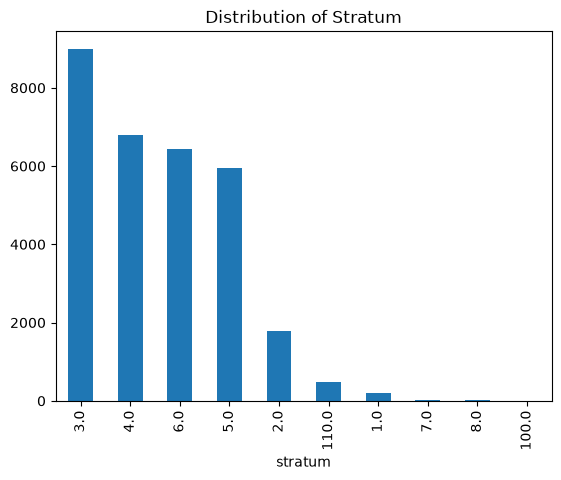

In [5]:
df["stratum"].value_counts().plot(kind="bar", title="Distribution of Stratum")

In [6]:
df["stratum"].value_counts()

stratum
3.00      8997
4.00      6785
6.00      6425
5.00      5947
2.00      1781
110.00     481
1.00       190
7.00        29
8.00        17
100.00       6
Name: count, dtype: int64

In [7]:
df["floor"].value_counts()  # when a floor is like nxx, the n is the floor
# number, and the xx is the apartment number. So, 3xx means floor 3.

floor
1.00      2987
2.00      2884
3.00      2497
4.00      1895
5.00      1579
6.00       866
7.00       584
8.00       383
18.00      307
9.00       247
10.00      218
12.00      216
11.00      190
16.00      108
13.00      108
14.00      101
15.00       99
17.00       46
20.00       23
19.00       22
21.00       14
22.00       14
27.00        9
24.00        8
25.00        6
23.00        6
29.00        6
28.00        5
26.00        4
32.00        3
30.00        3
101.00       3
301.00       3
608.00       2
44.00        2
403.00       2
402.00       2
303.00       2
102.00       2
203.00       2
502.00       2
211.00       1
902.00       1
501.00       1
801.00       1
505.00       1
404.00       1
701.00       1
601.00       1
35.00        1
Name: count, dtype: int64

In [8]:
(533 / df.shape[0]) * 100

1.7054908485856903

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31252 entries, 0 to 31251
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          31252 non-null  int64  
 1   operation           31252 non-null  str    
 2   property_type       31252 non-null  str    
 3   price_amount        31252 non-null  float64
 4   price_currency      31252 non-null  str    
 5   admin_fee           17641 non-null  float64
 6   total_monthly_cost  0 non-null      float64
 7   price_per_m2        25206 non-null  float64
 8   area_built_m2       25206 non-null  float64
 9   area_private_m2     23129 non-null  float64
 10  bedrooms            31252 non-null  int64  
 11  bathrooms           31252 non-null  int64  
 12  parking_spaces      20470 non-null  float64
 13  stratum             30658 non-null  float64
 14  floor               15469 non-null  float64
 15  floors_total        31252 non-null  int64  
 16  age_bracket_cod

# Look for inconsistent coordinates

In [10]:
geo_check = count_outside_bogota(df.latitude, df.longitude)
print(geo_check)

outside = outside_bbox_mask(df.latitude, df.longitude)
df.loc[outside, ["city", "latitude", "longitude"]]

{'total': 31252, 'inside': 31228, 'outside': 24, 'missing': 0, 'pct_outside': 0.08, 'bbox': BBox(lat_min=3.65, lat_max=5.85, lon_min=-75.0, lon_max=-73.0)}


,city,latitude,longitude
173,Cali,3.44,-76.51
782,Cali,3.44,-76.51
1547,Bucaramanga,7.15,-73.13
2136,Bogotá,20.97,-101.28
2210,NaN,0.00,0.00
2247,Medellín,6.30,-75.57
2305,NaN,0.00,0.00
2550,Cali,3.44,-76.51
2671,Bucaramanga,7.12,-73.12
2889,Bogotá,22.73,-105.35


# First Plots

In [11]:
categorical_columns = {
    "operation",
    "property_type",
    "price_currency",
    "stratum",
    "age_bracket_code",
    "age_bracket_label",
    "construction_state",
    "city",
    "locality",
    "neighborhood",
    "amenities",
    "agency_name",
    "publisher_type",
}

continuous_columns = {
    "price_amount",
    "admin_fee",
    "total_monthly_cost",
    "price_per_m2",
    "area_built_m2",
    "area_private_m2",
    "latitude",
    "longitude",
}

discrete_columns = {
    "bedrooms",
    "bathrooms",
    "parking_spaces",
    "floor",
    "floors_total",
}

# In none of the three: listing_id (identifier), address_text and
# source_url (free text), published_at and updated_at (dates).

d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:5779: UserWarning: Column 'stratum' is numeric but has only 10 distinct value(s), so it is treated as categorical. Override with treat_as={'stratum': 'numeric'} or the constructor's as_numeric=['stratum'].
  kind_x = self.resolve_kind(xs, treat.get(str(xs.name)))
D:\Temp\ipykernel_15500\453996426.py:4: UserWarning: barplot('stratum'): dropped 594 row(s) (1.9%) with nulls in stratum; n = 30,658 remain.
  plotter.barplot(
d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:1542: UserWarning: 10 levels exceed the 8-colour categorical palette; colours will repeat. Consider top_n=... or faceting.
  colors = self._palette_colors(len(cached) + len(missing), palette)


Error plotting city: 'city' has 76 levels, above the max_levels_error limit of 50. Pass top_n=... to keep only the most frequent levels.
Error plotting neighborhood: 'neighborhood' has 1272 levels, above the max_levels_error limit of 50. Pass top_n=... to keep only the most frequent levels.


D:\Temp\ipykernel_15500\453996426.py:4: UserWarning: barplot('construction_state'): dropped 1,558 row(s) (5.0%) with nulls in construction_state; n = 29,694 remain.
  plotter.barplot(
d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:5779: UserWarning: Column 'age_bracket_code' is numeric but has only 6 distinct value(s), so it is treated as categorical. Override with treat_as={'age_bracket_code': 'numeric'} or the constructor's as_numeric=['age_bracket_code'].
  kind_x = self.resolve_kind(xs, treat.get(str(xs.name)))
D:\Temp\ipykernel_15500\453996426.py:4: UserWarning: barplot('age_bracket_code'): dropped 762 row(s) (2.4%) with nulls in age_bracket_code; n = 30,490 remain.
  plotter.barplot(
D:\Temp\ipykernel_15500\453996426.py:4: UserWarning: barplot('amenities'): dropped 2,875 row(s) (9.2%) with nulls in amenities; n = 28,377 remain.
  plotter.barplot(


Error plotting amenities: 'amenities' has 23142 levels, above the max_levels_error limit of 50. Pass top_n=... to keep only the most frequent levels.


D:\Temp\ipykernel_15500\453996426.py:4: UserWarning: barplot('locality'): dropped 4,623 row(s) (14.8%) with nulls in locality; n = 26,629 remain.
  plotter.barplot(
D:\Temp\ipykernel_15500\453996426.py:4: UserWarning: barplot('agency_name'): dropped 1,115 row(s) (3.6%) with nulls in agency_name; n = 30,137 remain.
  plotter.barplot(
D:\Temp\ipykernel_15500\453996426.py:4: UserWarning: barplot('publisher_type'): dropped 1,115 row(s) (3.6%) with nulls in publisher_type; n = 30,137 remain.
  plotter.barplot(
D:\Temp\ipykernel_15500\453996426.py:4: UserWarning: barplot('age_bracket_label'): dropped 762 row(s) (2.4%) with nulls in age_bracket_label; n = 30,490 remain.
  plotter.barplot(


Error plotting agency_name: 'agency_name' has 1253 levels, above the max_levels_error limit of 50. Pass top_n=... to keep only the most frequent levels.


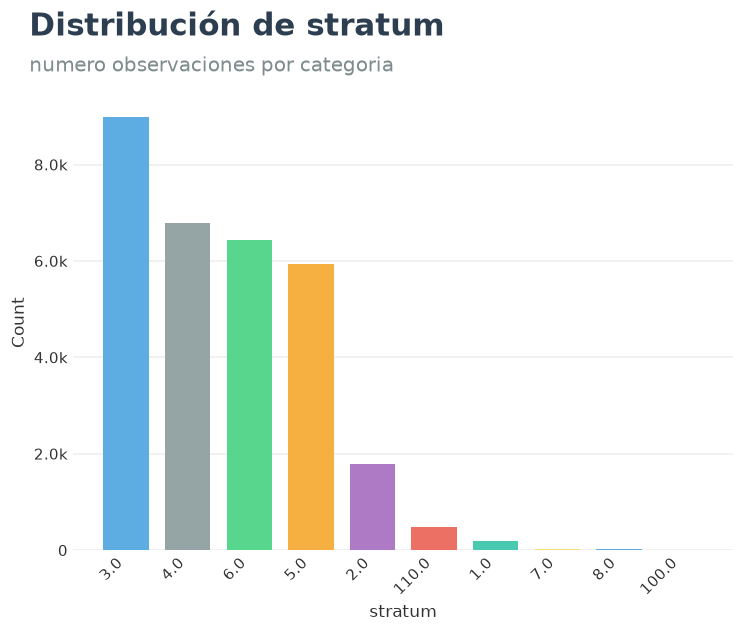

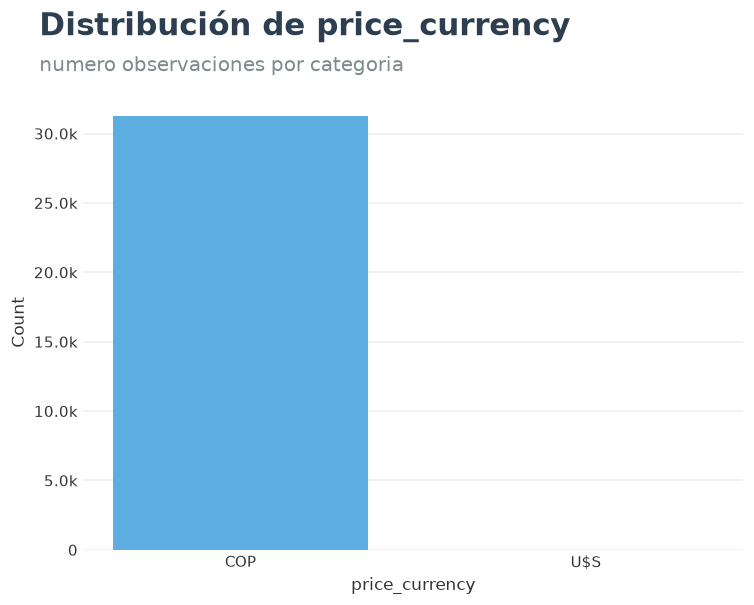

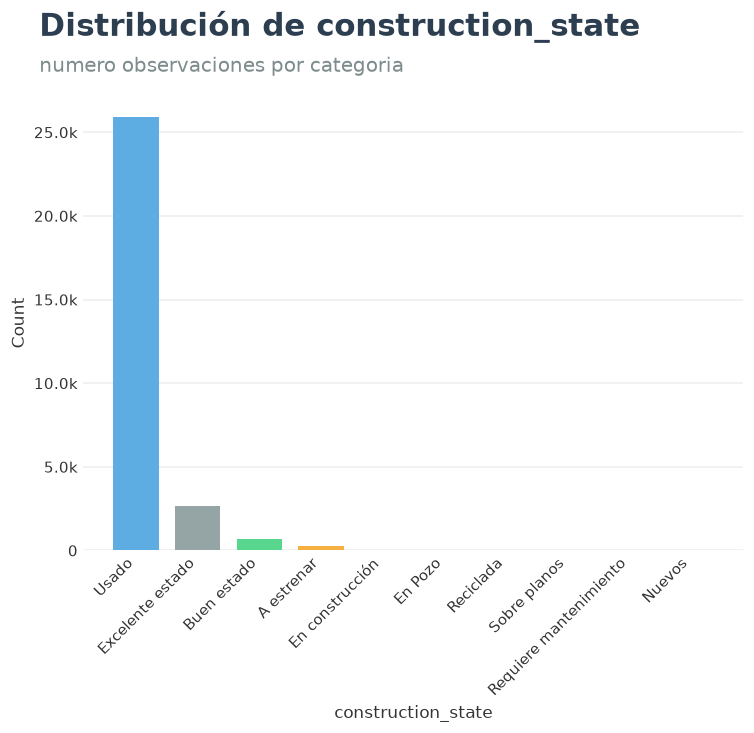

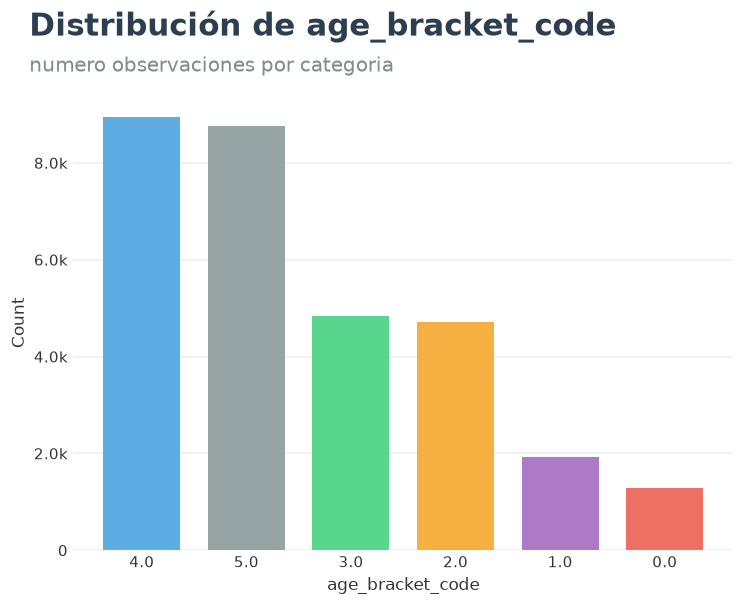

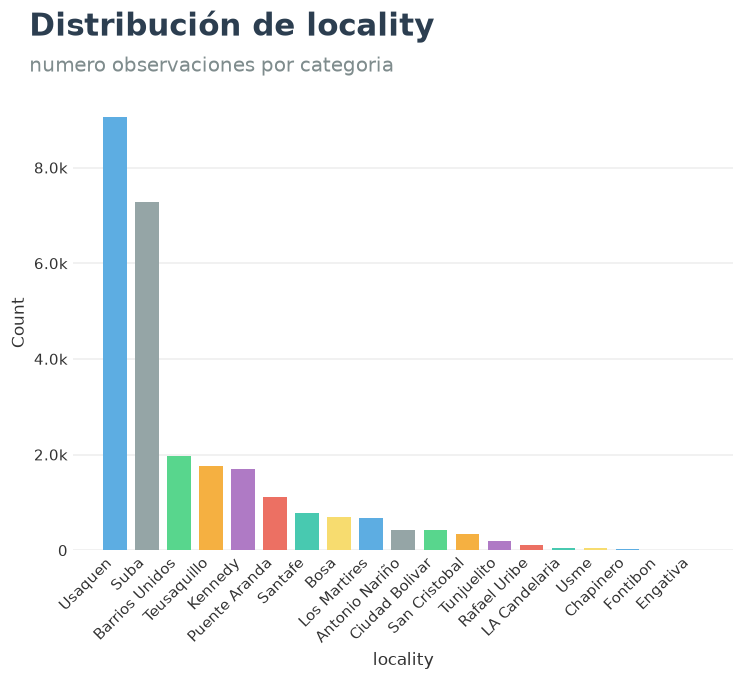

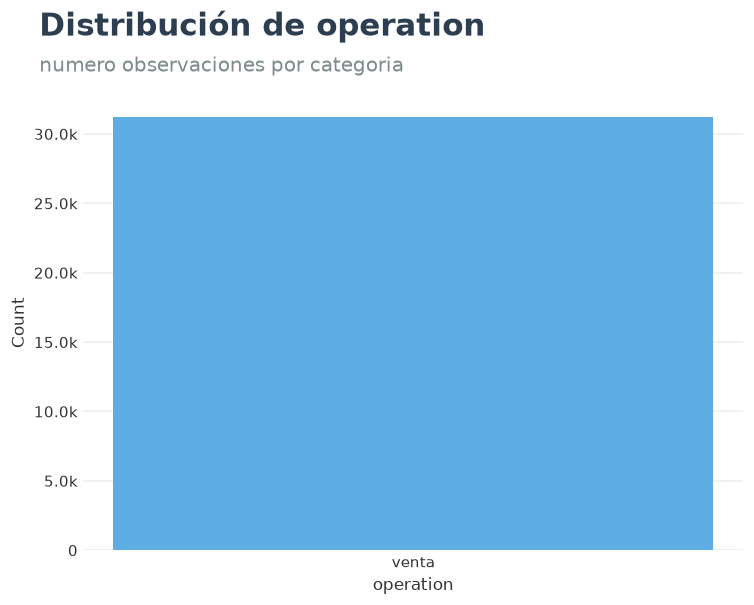

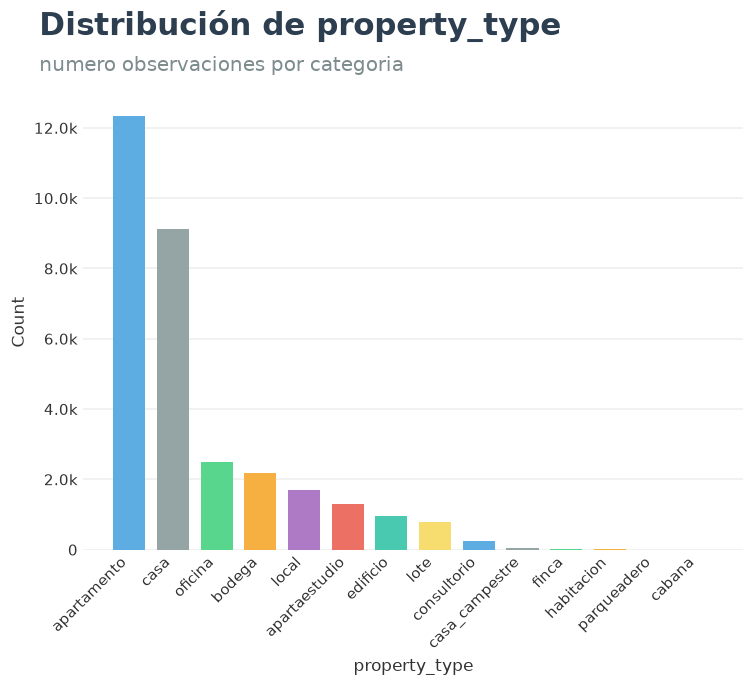

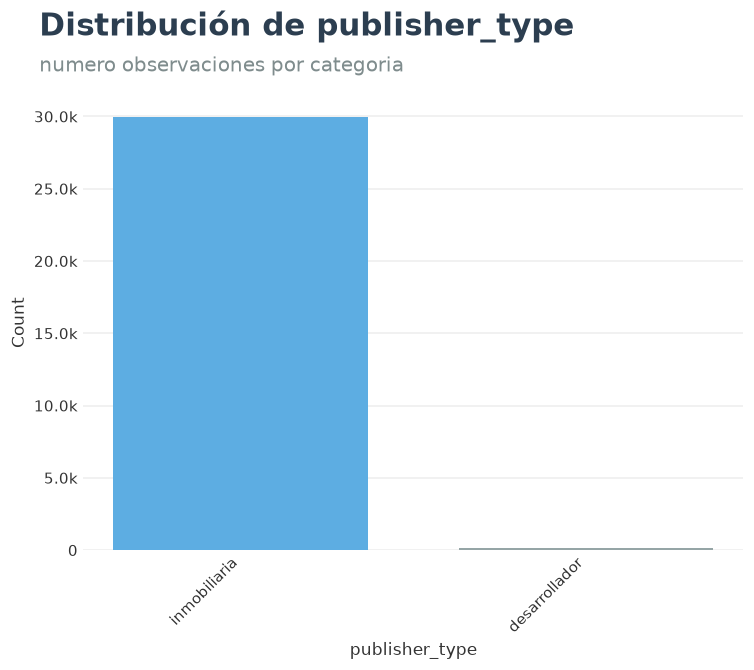

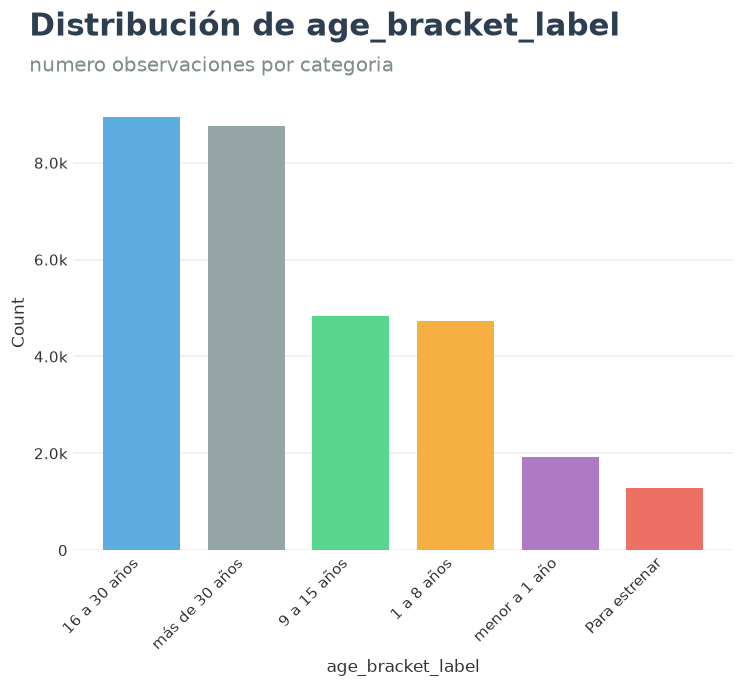

In [12]:
plotter = EDAPlotter(df)
for col in categorical_columns:
    try:
        plotter.barplot(
            x=col,
            title=f"Distribución de {col}",
            subtitle="numero observaciones por categoria",
            )
    except Exception as e:
        print(f"Error plotting {col}: {e}")

In [13]:
df.shape

(31252, 31)

d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:5614: UserWarning: x='parking_spaces' is continuous numeric; counting its raw values rarely reads well. Consider histplot, or bin it first.
  cat, value, hue_extra, orient = self._resolve_bar_axes(
D:\Temp\ipykernel_15500\3941247575.py:3: UserWarning: barplot('parking_spaces'): dropped 10,782 row(s) (34.5%) with nulls in parking_spaces; n = 20,470 remain.
  plotter.barplot(
d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:5614: UserWarning: x='floors_total' is continuous numeric; counting its raw values rarely reads well. Consider histplot, or bin it first.
  cat, value, hue_extra, orient = self._resolve_bar_axes(
d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:5635: UserWarning: 'floors_total' has 44 levels, which will be hard to read. Consider top_n=... to keep only the most frequent ones.
  work[cat_name] = self._limit_level

Error plotting parking_spaces: 'parking_spaces' has 54 levels, above the max_levels_error limit of 50. Pass top_n=... to keep only the most frequent levels.


d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:5614: UserWarning: x='floor' is continuous numeric; counting its raw values rarely reads well. Consider histplot, or bin it first.
  cat, value, hue_extra, orient = self._resolve_bar_axes(
D:\Temp\ipykernel_15500\3941247575.py:3: UserWarning: barplot('floor'): dropped 15,783 row(s) (50.5%) with nulls in floor; n = 15,469 remain.
  plotter.barplot(
d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:5635: UserWarning: 'floor' has 50 levels, which will be hard to read. Consider top_n=... to keep only the most frequent ones.
  work[cat_name] = self._limit_levels(work[cat_name], top_n)
d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:5614: UserWarning: x='bedrooms' is continuous numeric; counting its raw values rarely reads well. Consider histplot, or bin it first.
  cat, value, hue_extra, orient = self._resolve_bar_axes(
d:\Externado\

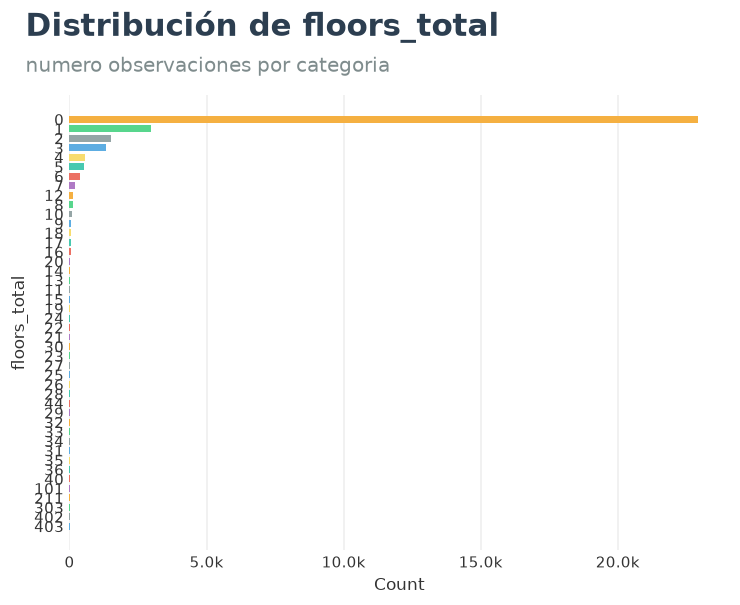

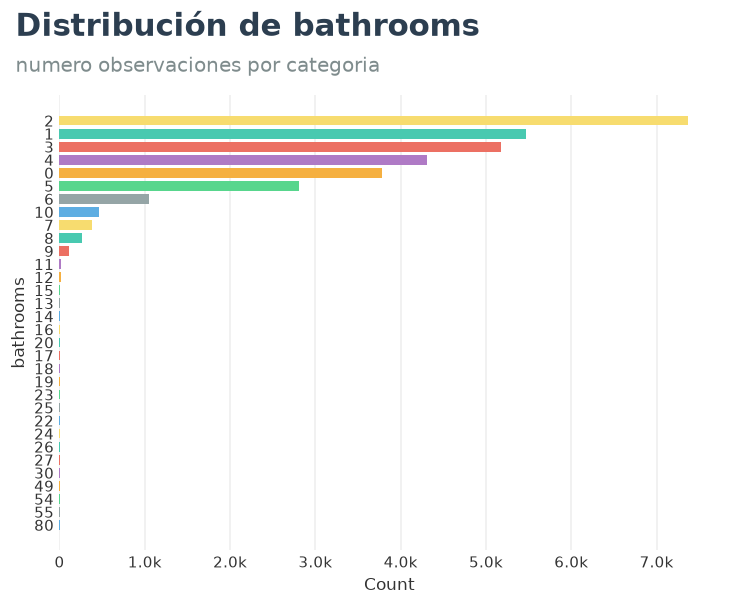

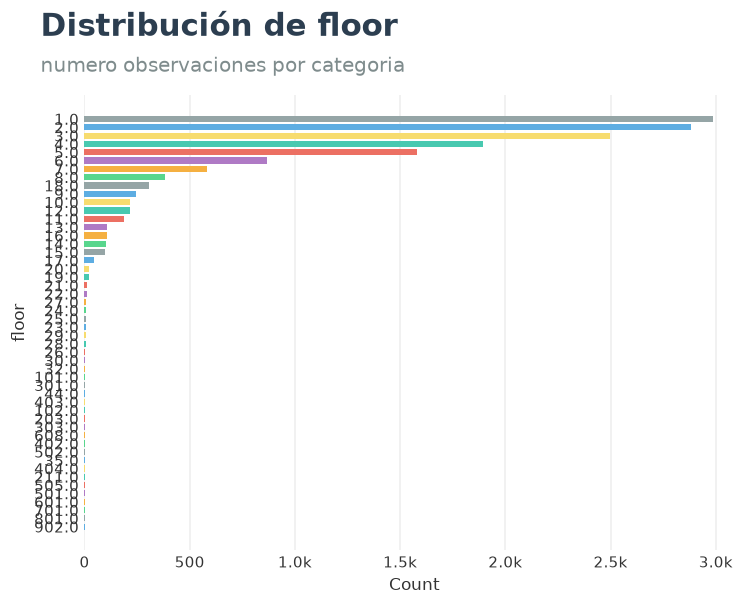

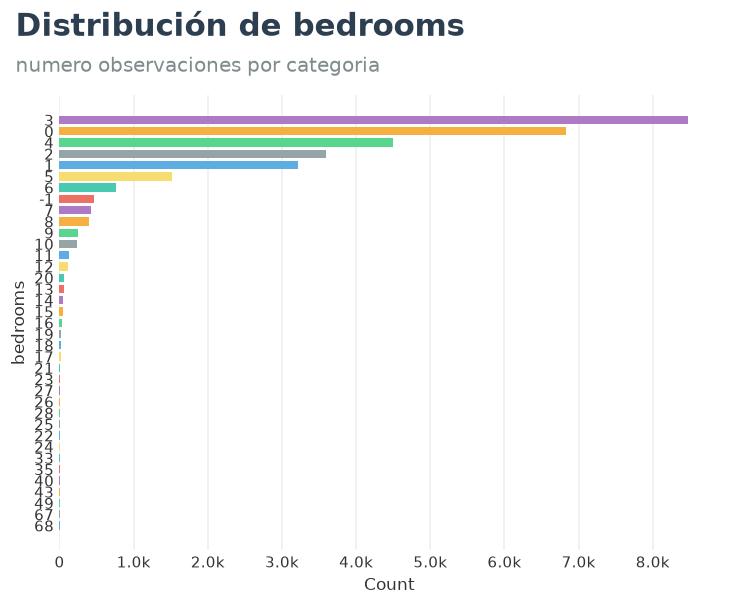

In [14]:
for col in discrete_columns:
    try:
        plotter.barplot(
            y=col,
            title=f"Distribución de {col}",
            subtitle="numero observaciones por categoria",
            rotate_xticks = 90,
            orientation = "horizontal"
            )
    except Exception as e:
        print(f"Error plotting {col}: {e}")

findfont: Failed to find font weight medium, now using 400.


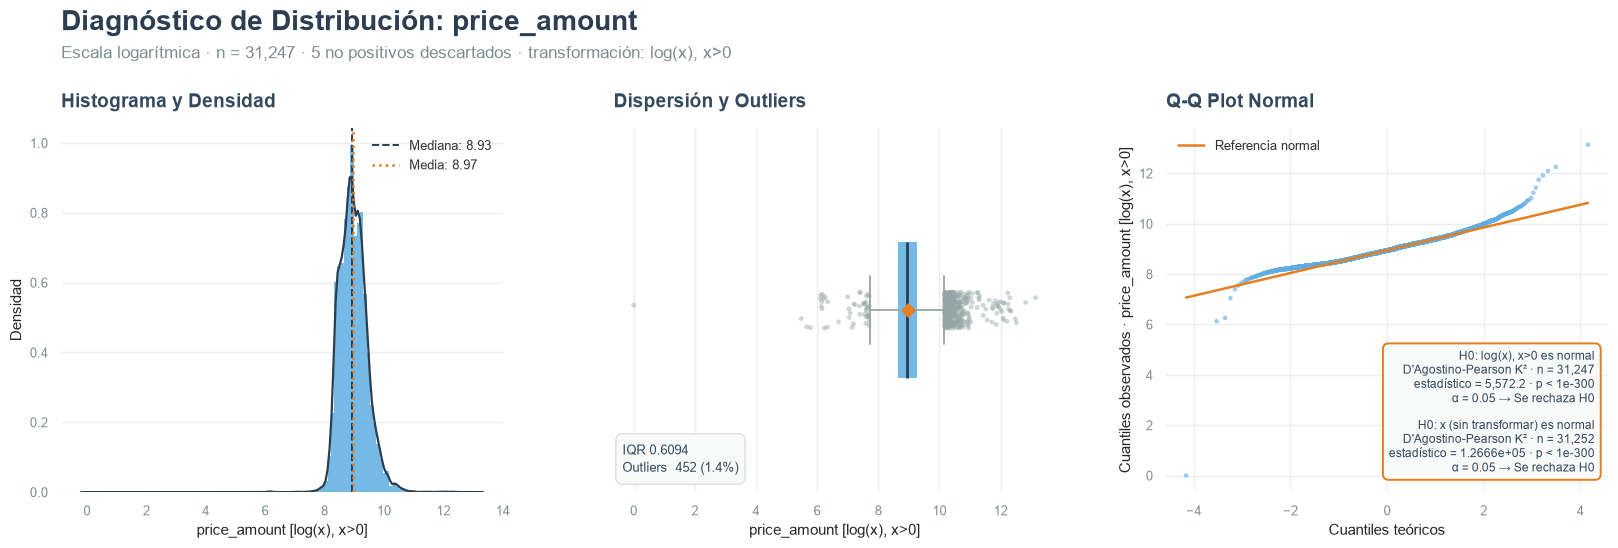

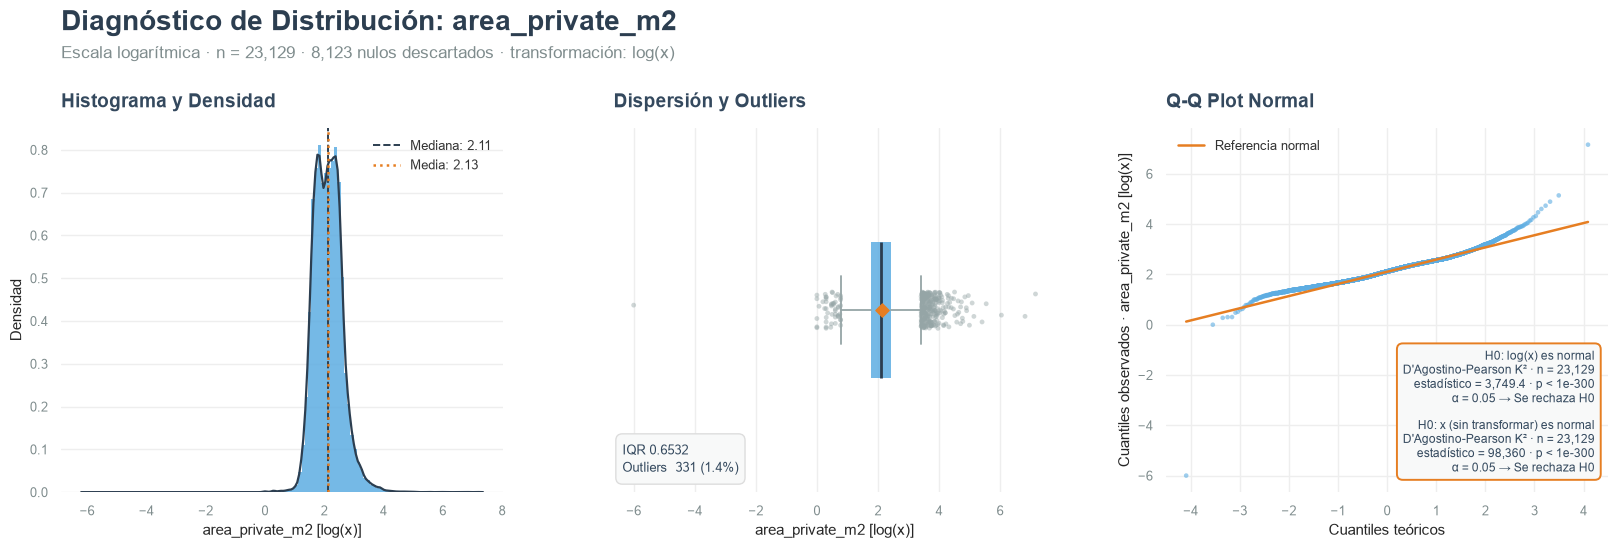

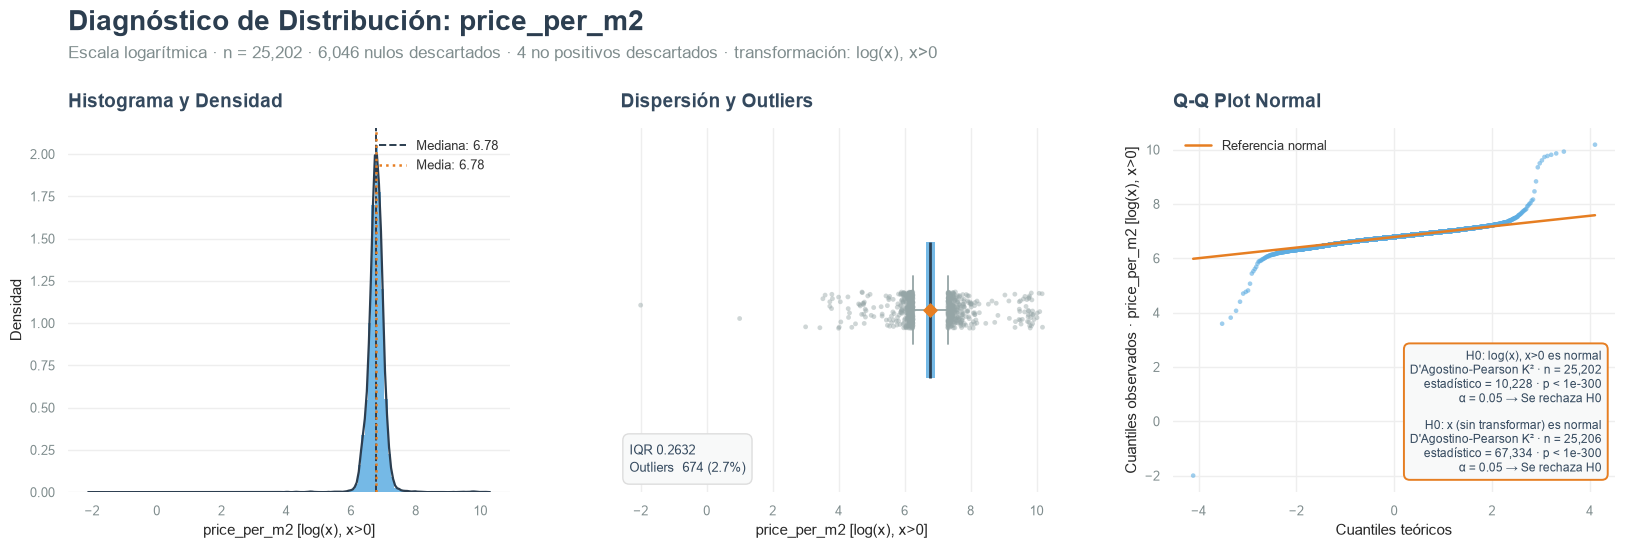

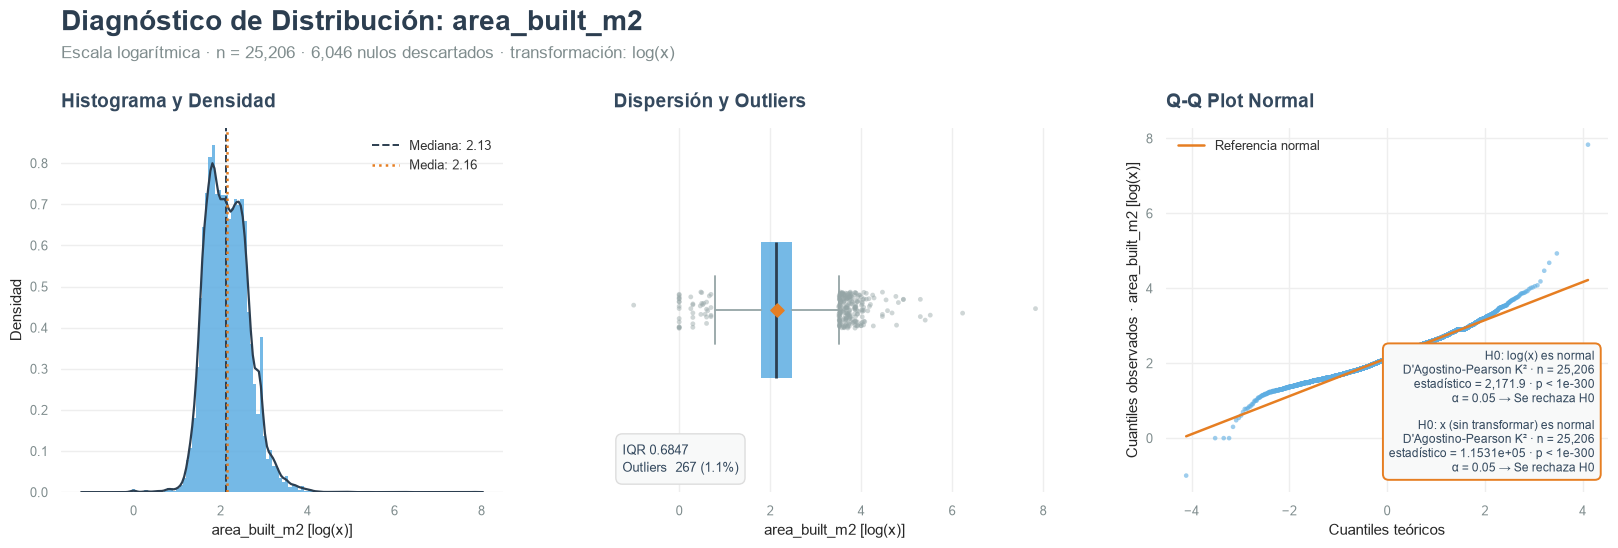

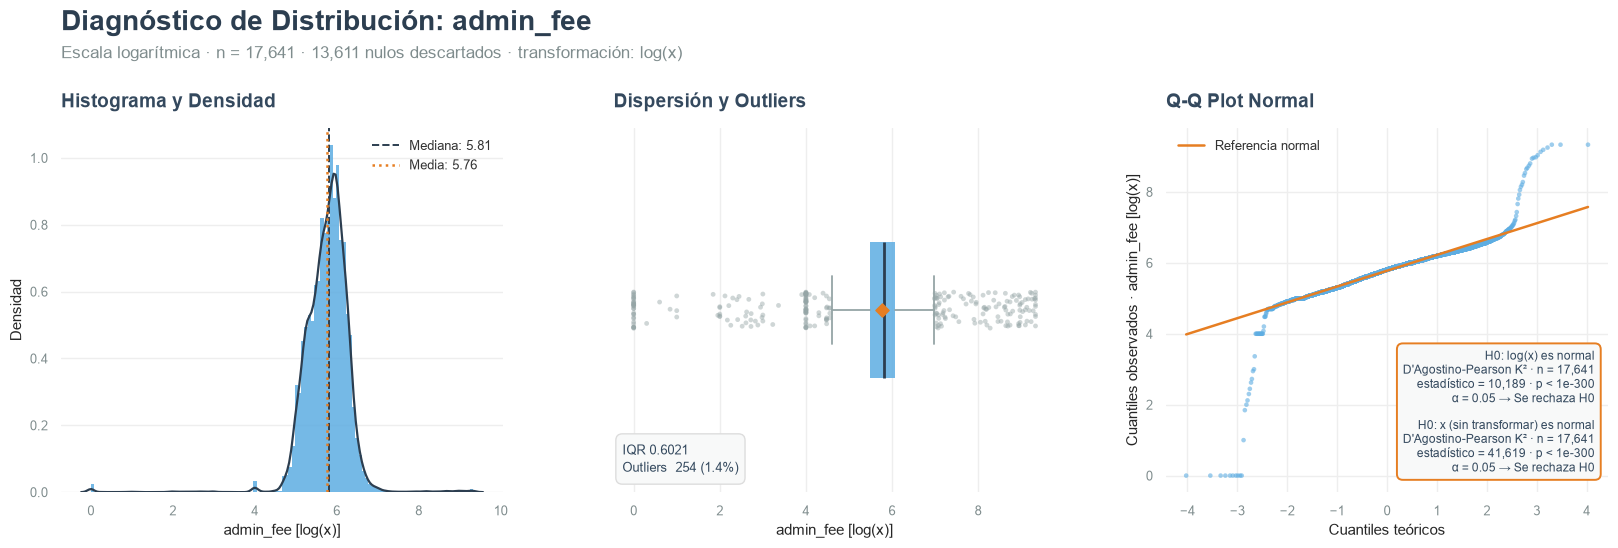

In [15]:
for col in continuous_columns:
    if col in ["latitude", "longitude", "total_monthly_cost"]:
        continue
    normality_report(df, col, log_scale=True, kde=True, test="auto", neg_strategy="drop")

## Interesting Means

In [16]:
df["price_amount"].describe()

count            31252.00
mean        3644250869.26
std        96776331244.01
min                  0.00
25%          440000000.00
50%          860000000.00
75%         1790000000.00
max     13789000000000.00
Name: price_amount, dtype: float64

In [17]:
df["area_private_m2"].describe()

count      23129.00
mean        1311.98
std       104232.03
min            0.00
25%           60.00
50%          130.00
75%          270.00
max     14390000.00
Name: area_private_m2, dtype: float64

# NaN's values

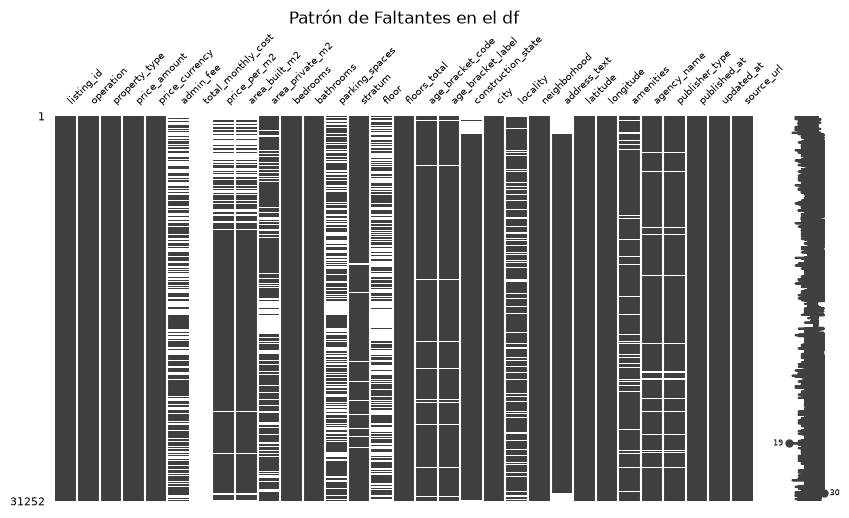

In [18]:
n_cols = len(df.columns)
ancho = max(10, int(n_cols * 0.35))
alto = 5

tamano_letra = max(6, 10 - n_cols // 10)

try:

    msno.matrix(df, figsize=(ancho, alto), fontsize=tamano_letra)
    plt.title('Patrón de Faltantes en el df')
    plt.show()

except Exception:
    plt.figure(figsize=(ancho, alto))
    missing_pattern = df.isnull()

    plt.imshow(missing_pattern.astype(int), aspect='auto', cmap='RdYlGn_r')

    plt.xticks(
        ticks=range(n_cols),
        labels=missing_pattern.columns,
        rotation=90,
        fontsize=tamano_letra,
        ha='center'
    )
    plt.yticks([])
    plt.title('Patrón de Faltantes (blanco = faltante)')
    plt.colorbar(label='1=Faltante, 0=Presente')

    plt.tight_layout()  # Evita que las etiquetas se corten abajo
    plt.show()

# A correlation glance

d:\Externado\Cuarto semestre\bayesiana\proyecto_finca_raiz_colombia\utils\plotting.py:8491: UserWarning: Column 'total_monthly_cost' is numeric but has only 0 distinct value(s), so it is treated as categorical. Override with treat_as={'total_monthly_cost': 'numeric'} or the constructor's as_numeric=['total_monthly_cost'].
  kind = self.resolve_kind(frame[column], treat.get(column))
D:\Temp\ipykernel_15500\1876312318.py:1: UserWarning: corr_heatmap excluded 3 numeric-but-low-cardinality column(s) (total_monthly_cost, stratum, age_bracket_code): a correlation over a small integer code is usually misleading. Pass include_low_cardinality=True to keep them.
  plotter.corr_heatmap(


<Axes: >

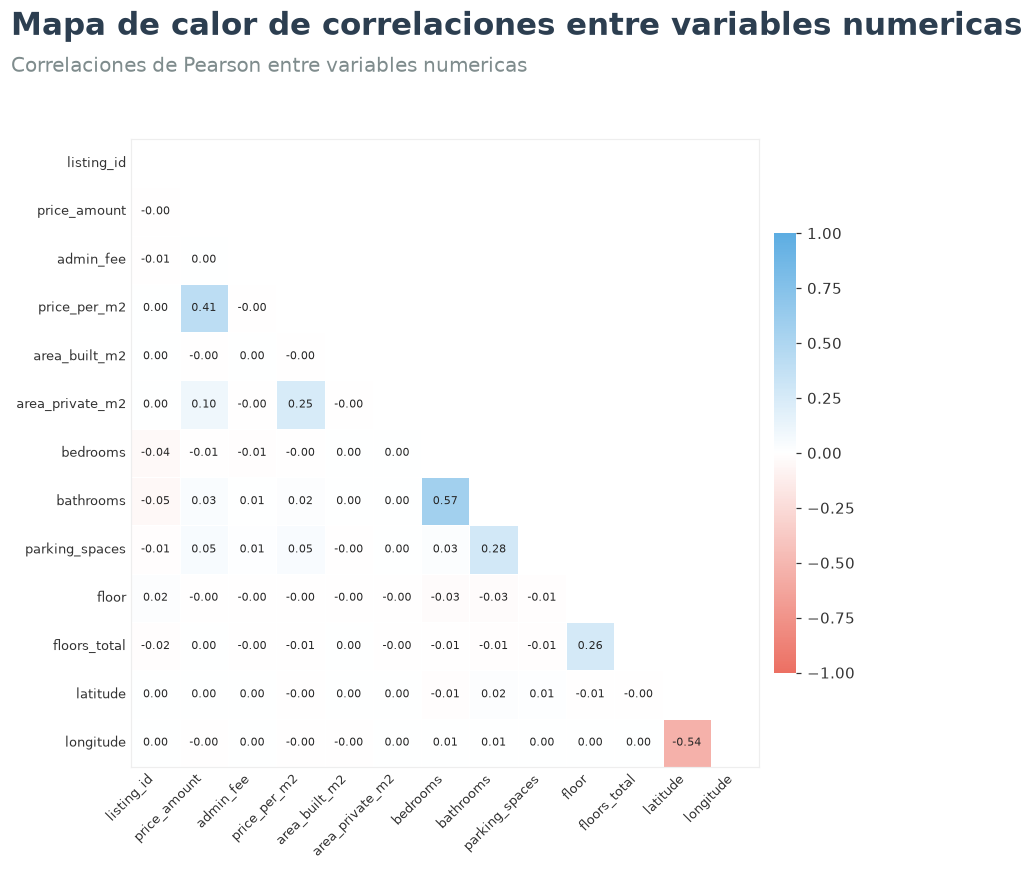

In [19]:
plotter.corr_heatmap(
    title="Mapa de calor de correlaciones entre variables numericas",
    subtitle="Correlaciones de Pearson entre variables numericas",
    annot=True)

D:\Temp\ipykernel_15500\3742601343.py:1: UserWarning: corr_heatmap excluded 3 numeric-but-low-cardinality column(s) (total_monthly_cost, stratum, age_bracket_code): a correlation over a small integer code is usually misleading. Pass include_low_cardinality=True to keep them.
  plotter.corr_heatmap(


<Axes: >

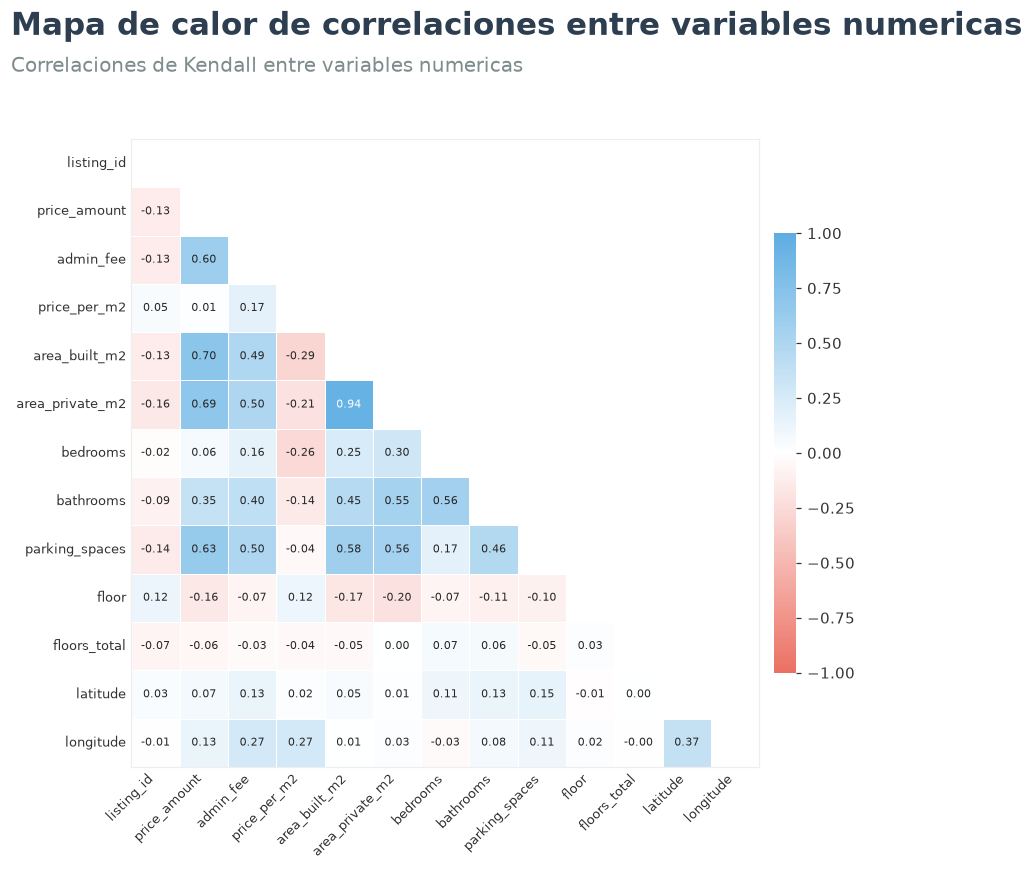

In [20]:
plotter.corr_heatmap(
    title="Mapa de calor de correlaciones entre variables numericas",
    subtitle="Correlaciones de Kendall entre variables numericas",
    method="kendall",
    annot=True)